# 08 — Results Aggregation

Loads all `metrics.json` files from `results/runs/` and produces the four tables / figures the paper needs.

Run this after every new model completes — it handles missing runs gracefully.

**Outputs:**
- `results/figures/platform_breakdown.png` — Twitter vs Reddit bar chart
- Tables printed inline for copy-paste into the paper

In [12]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sys.path.insert(0, '..')

RUNS_DIR    = Path('../results/runs')
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Canonical run_name for each model shown in the paper.
# For LLMs the best variant is CoT — update if results say otherwise.
BEST_RUNS = {
    'LSTM':               'lstm',
    'MentalBERT':         'mentalbert',
    'RoBERTa':            'roberta',
    'GPT-5.4-mini zero-shot':    'gpt_zero_shot',
    'GPT-5.4-mini few-shot':     'gpt_few_shot',
    'GPT-5.4-mini CoT':          'gpt_chain_of_thought',
    'Gemini 3 Flash zero-shot':  'gemini_zero_shot',
    'Gemini 3 Flash few-shot':   'gemini_few_shot',
    'Gemini 3 Flash CoT':        'gemini_chain_of_thought',
}

ENCODER_LR_RUNS = {
    'MentalBERT': [('1e-5', 'mentalbert_lr1e5'), ('2e-5', 'mentalbert'), ('3e-5', 'mentalbert_lr3e5')],
    'RoBERTa':    [('1e-5', 'roberta_lr1e5'),    ('2e-5', 'roberta'),    ('3e-5', 'roberta_lr3e5')],
}

def load_metrics(run_id: str) -> dict | None:
    path = RUNS_DIR / run_id / 'metrics.json'
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

print('Config loaded.')

Config loaded.


## 1 — Load available results

In [13]:
available: dict[str, dict] = {}

for name, run_id in BEST_RUNS.items():
    m = load_metrics(run_id)
    if m is not None:
        available[name] = m
        print(f'  ✓  {name:<26} macro-F1={m["macro_f1"]:.4f}')
    else:
        print(f'  ○  {name:<26} — not yet available')

print(f'\n{len(available)} / {len(BEST_RUNS)} models loaded')

  ✓  LSTM                       macro-F1=0.5246
  ✓  MentalBERT                 macro-F1=0.6775
  ✓  RoBERTa                    macro-F1=0.6788
  ✓  GPT-5.4-mini zero-shot     macro-F1=0.5876
  ✓  GPT-5.4-mini few-shot      macro-F1=0.5311
  ✓  GPT-5.4-mini CoT           macro-F1=0.6047
  ✓  Gemini 3 Flash zero-shot   macro-F1=0.5513
  ✓  Gemini 3 Flash few-shot    macro-F1=0.5678
  ✓  Gemini 3 Flash CoT         macro-F1=0.5540

9 / 9 models loaded


## 2 — Main comparison table  *(paper Table 1)*

Macro-F1 with 95% bootstrap CI, accuracy, and per-platform slice.

In [14]:
rows = []
for name, m in available.items():
    tw = m['by_source'].get('twitter', {}).get('macro_f1', float('nan'))
    re = m['by_source'].get('reddit',  {}).get('macro_f1', float('nan'))
    rows.append({
        'Model':      name,
        'Macro-F1':   round(m['macro_f1'], 4),
        '95% CI':     f"[{m['macro_f1_ci_low']:.3f}\u2013{m['macro_f1_ci_high']:.3f}]",
        'Accuracy':   round(m['accuracy'], 4),
        'Twitter F1': round(tw, 4),
        'Reddit F1':  round(re, 4),
        '\u0394 Tw\u2013Re': round(tw - re, 4) if tw == tw and re == re else float('nan'),
    })

df_main = (
    pd.DataFrame(rows)
    .set_index('Model')
    .sort_values('Macro-F1', ascending=False)
)
df_main.style.background_gradient(subset=['Macro-F1'], cmap='Greens', vmin=0.4, vmax=0.85)

,Macro-F1,95% CI,Accuracy,Twitter F1,Reddit F1,Δ Tw–Re
Model,,,,,,
RoBERTa,0.678800,[0.643–0.714],0.751200,0.716100,0.487400,0.228800
MentalBERT,0.677500,[0.642–0.710],0.757000,0.737200,0.426300,0.310800
GPT-5.4-mini CoT,0.604700,[0.566–0.645],0.716600,0.653000,0.389200,0.263800
GPT-5.4-mini zero-shot,0.587600,[0.551–0.623],0.681100,0.623200,0.420200,0.203000
Gemini 3 Flash few-shot,0.567800,[0.528–0.606],0.691600,0.583000,0.457800,0.125200
Gemini 3 Flash CoT,0.554000,[0.516–0.588],0.684900,0.568500,0.458100,0.110400
Gemini 3 Flash zero-shot,0.551300,[0.515–0.586],0.675300,0.559100,0.496100,0.063000
GPT-5.4-mini few-shot,0.531100,[0.497–0.565],0.620600,0.547500,0.419500,0.128000
LSTM,0.524600,[0.487–0.561],0.614800,0.545300,0.387700,0.157600


## 3 — Per-class F1  *(paper Table 2)*

F1 per severity class for the paper models (best variant per family).

In [15]:
PAPER_ORDER = ['LSTM', 'MentalBERT', 'RoBERTa', 'GPT-5.4-mini CoT', 'Gemini 3 Flash CoT']
rows = []
for name in PAPER_ORDER:
    m = available.get(name)
    if m is None:
        continue
    row = {'Model': name, 'Macro-F1': round(m['macro_f1'], 4)}
    for cls in ['minimum', 'mild', 'moderate', 'severe']:
        row[cls.capitalize()] = round(m['per_class'][cls]['f1'], 3) if cls in m.get('per_class', {}) else None
    rows.append(row)

if rows:
    df_pc = pd.DataFrame(rows).set_index('Model')
    display(df_pc.style.background_gradient(cmap='RdYlGn', vmin=0.2, vmax=0.9,
                                             subset=[c for c in df_pc.columns if c != 'Macro-F1']))
else:
    print('No paper models loaded yet.')

,Macro-F1,Minimum,Mild,Moderate,Severe
Model,,,,,
LSTM,0.524600,0.759000,0.518000,0.390000,0.431000
MentalBERT,0.677500,0.886000,0.656000,0.505000,0.662000
RoBERTa,0.678800,0.875000,0.654000,0.494000,0.692000
GPT-5.4-mini CoT,0.604700,0.854000,0.591000,0.402000,0.571000
Gemini 3 Flash CoT,0.554000,0.860000,0.501000,0.352000,0.503000


## 4 — Encoder LR sweep

In [16]:
rows = []
for family, variants in ENCODER_LR_RUNS.items():
    for lr, run_id in variants:
        m = load_metrics(run_id)
        if m is None:
            continue
        rows.append({
            'Model':    family,
            'LR':       lr,
            'Macro-F1': round(m['macro_f1'], 4),
            'CI':       f"[{m['macro_f1_ci_low']:.3f}\u2013{m['macro_f1_ci_high']:.3f}]",
            'Twitter':  round(m['by_source'].get('twitter', {}).get('macro_f1', float('nan')), 4),
            'Reddit':   round(m['by_source'].get('reddit',  {}).get('macro_f1', float('nan')), 4),
        })

if rows:
    display(pd.DataFrame(rows).set_index(['Model', 'LR']))
else:
    print('No encoder LR sweep results found.')

Macro-F1             CI  Twitter  Reddit
Model      LR                                            
MentalBERT 1e-5    0.6691  [0.634–0.703]   0.7217  0.4161
           2e-5    0.6775  [0.642–0.710]   0.7372  0.4263
           3e-5    0.6599  [0.623–0.695]   0.7230  0.4251
RoBERTa    1e-5    0.6628  [0.628–0.699]   0.6863  0.4696
           2e-5    0.6788  [0.643–0.714]   0.7161  0.4874
           3e-5    0.6700  [0.635–0.704]   0.6978  0.5110

## 5 — LLM prompt ablation

Zero-shot vs few-shot vs chain-of-thought per LLM family.

In [20]:
LLM_GROUPS = {
    'GPT-5.4-mini': ['GPT-5.4-mini zero-shot', 'GPT-5.4-mini few-shot', 'GPT-5.4-mini CoT'],
    'Gemini 3 Flash': ['Gemini 3 Flash zero-shot', 'Gemini 3 Flash few-shot', 'Gemini 3 Flash CoT'],
}

rows = []
for family, variants in LLM_GROUPS.items():
    for v in variants:
        m = available.get(v)
        if m is None:
            continue
        tw = m['by_source'].get('twitter', {}).get('macro_f1', float('nan'))
        re = m['by_source'].get('reddit',  {}).get('macro_f1', float('nan'))
        rows.append({
            'Model':    family,
            'Variant':  v.split()[-1],
            'Macro-F1': round(m['macro_f1'], 4),
            'CI':       f"[{m['macro_f1_ci_low']:.3f}\u2013{m['macro_f1_ci_high']:.3f}]",
            'Twitter':  round(tw, 4),
            'Reddit':   round(re, 4),
        })

if rows:
    display(pd.DataFrame(rows).set_index(['Model', 'Variant']))
else:
    print('LLM results not yet available.')
    print('Run: python src/llm/run_llm_eval.py --model gemini --variant zero_shot')

Macro-F1             CI  Twitter  Reddit
Model          Variant                                            
GPT-5.4-mini   zero-shot    0.5876  [0.551–0.623]   0.6232  0.4202
               few-shot     0.5311  [0.497–0.565]   0.5475  0.4195
               CoT          0.6047  [0.566–0.645]   0.6530  0.3892
Gemini 3 Flash zero-shot    0.5513  [0.515–0.586]   0.5591  0.4961
               few-shot     0.5678  [0.528–0.606]   0.5830  0.4578
               CoT          0.5540  [0.516–0.588]   0.5685  0.4581

## 6 — Platform breakdown  *(paper figure)*

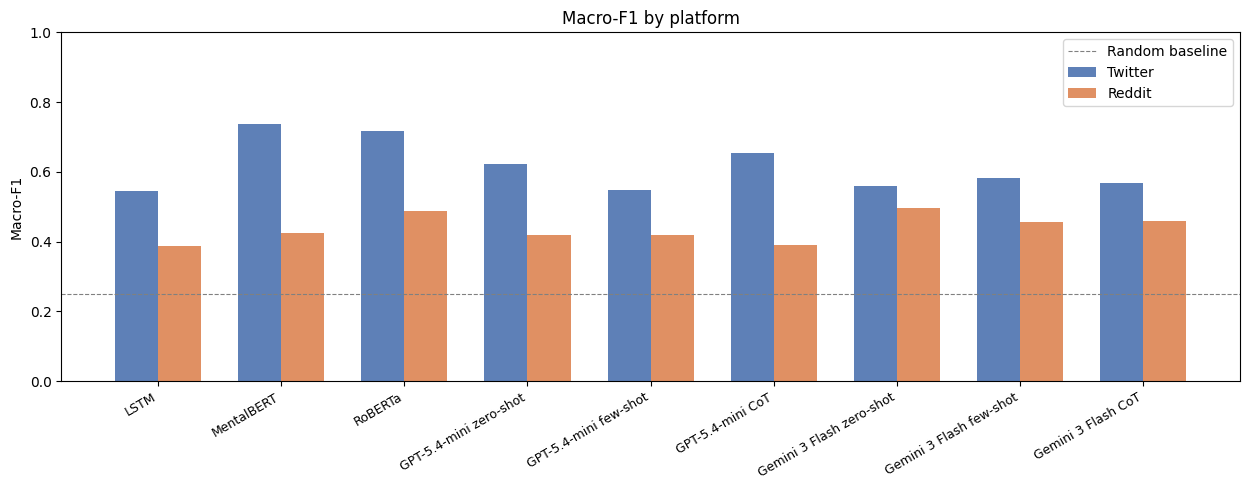

Saved -> ..\results\figures\platform_breakdown.png


In [18]:
if not available:
    print('No results loaded yet.')
else:
    models = list(available.keys())
    tw_scores = [available[m]['by_source'].get('twitter', {}).get('macro_f1', float('nan')) for m in models]
    re_scores = [available[m]['by_source'].get('reddit',  {}).get('macro_f1', float('nan')) for m in models]

    x = np.arange(len(models))
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(models) * 1.4), 5))
    ax.bar(x - w/2, tw_scores, w, label='Twitter', color='#4C72B0', alpha=0.9)
    ax.bar(x + w/2, re_scores, w, label='Reddit',  color='#DD8452', alpha=0.9)
    ax.axhline(0.25, color='gray', linewidth=0.8, linestyle='--', label='Random baseline')
    ax.set_ylabel('Macro-F1')
    ax.set_title('Macro-F1 by platform')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.legend()
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    out = FIGURES_DIR / 'platform_breakdown.png'
    fig.savefig(out, dpi=150)
    plt.show()
    print(f'Saved -> {out}')

## 7 — Confusion matrix gallery

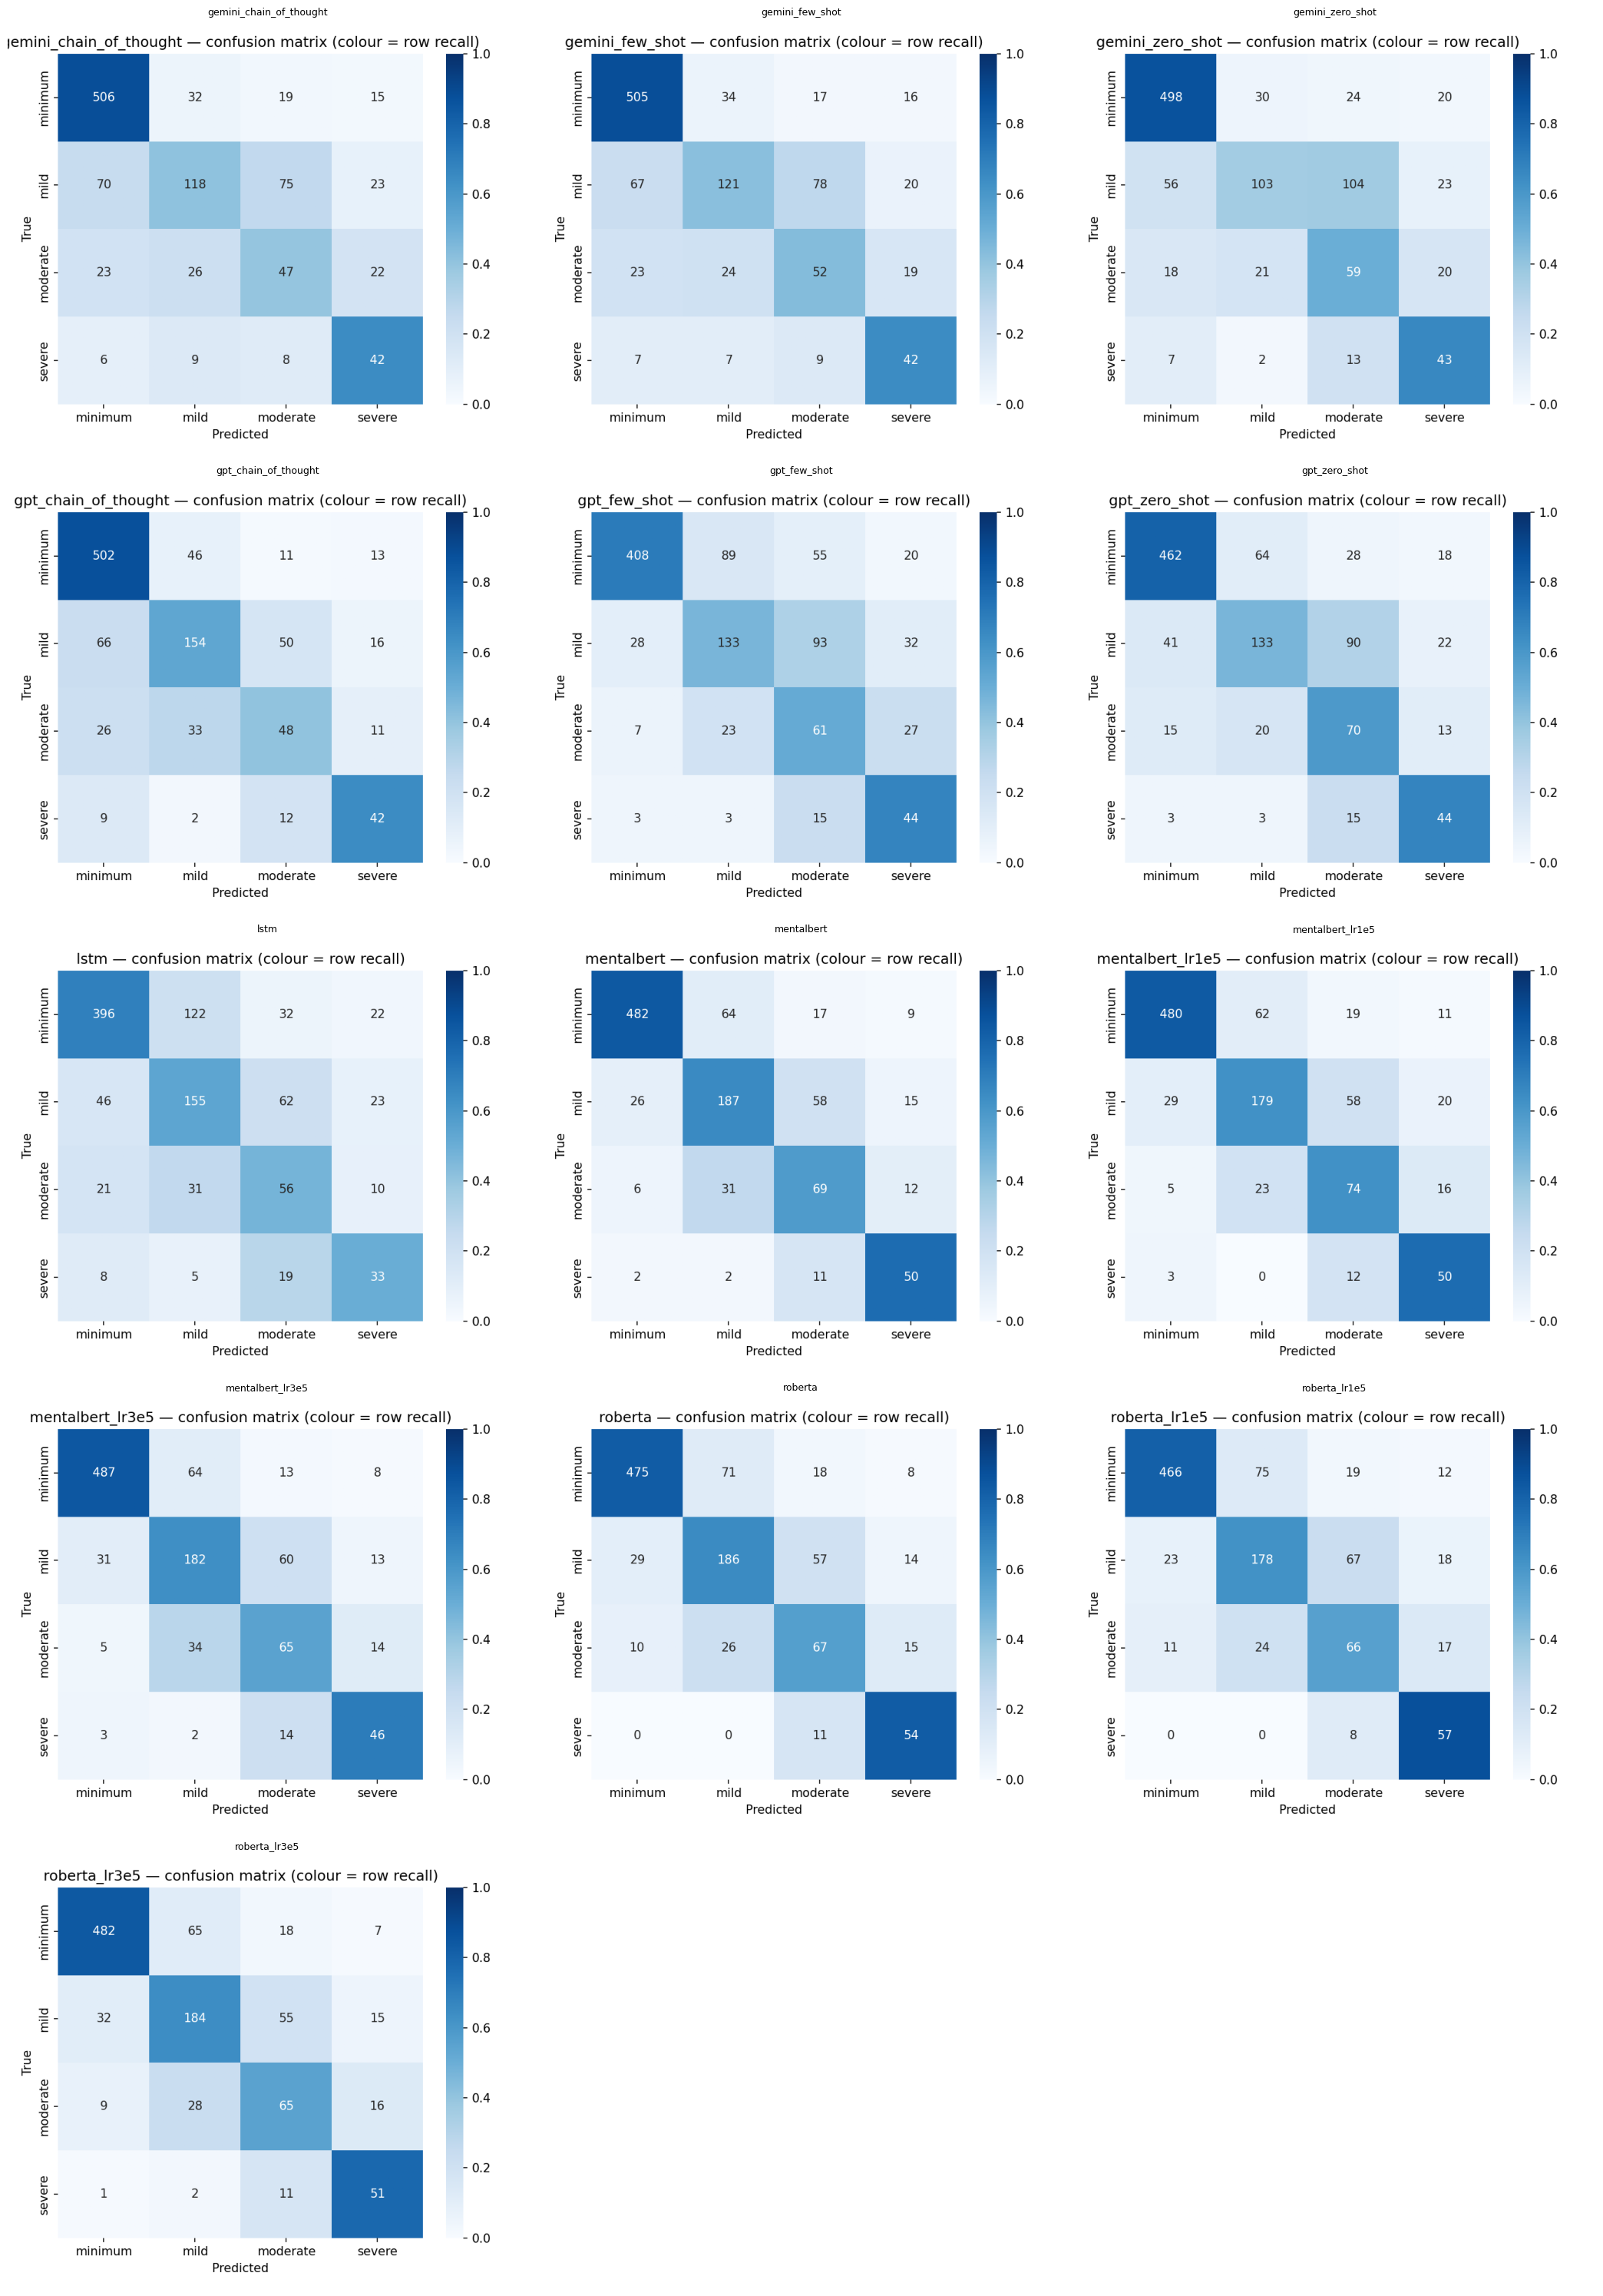

In [19]:
cm_files = sorted(RUNS_DIR.glob('*/[!_]*_confusion_matrix.png'))

if not cm_files:
    print('No confusion matrix PNGs found in results/runs/')
else:
    cols = min(3, len(cm_files))
    rows_n = (len(cm_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(7 * cols, 6 * rows_n))
    axes = np.array(axes).flatten()

    for ax, cm_path in zip(axes, cm_files):
        img = mpimg.imread(str(cm_path))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(cm_path.parent.name, fontsize=9)

    for ax in axes[len(cm_files):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()